# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql (a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.
- Note: the initial lab is opened as read only. To save work completed utilize the `save notebook as` option and give the lab a new name.

In [ ]:
import requests

# start a spark session and create a spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("nyc_taxi") \
    .getOrCreate()

sc = spark.sparkContext

In [2]:
# set dl url for January 2019 trip data
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

# get the data
response = requests.get(download_url)

# check that response was good and save the data
jan_2019_trip_data = "yellow_tripdata_2019-01.parquet"
if response.status_code == 200:
    # Changed 'response' to 'data' here
    with open(jan_2019_trip_data, "wb") as f:
        f.write(response.content)


In [3]:
# create the dataframe
df_trips = spark.read.parquet(jan_2019_trip_data)

# A brief note on handling data sources in spark

The command above works well for loading data from parquet files because parquet is a self descibing file format, meaning that the metadata needed to build the dataframe is included directly in the format. However, when working with other formats such as csv or json, a schema must be provided or infered. In production code the schema should always be explicitly provided but during the data exploration phase it is acceptable to infer the schema, and when infering the schema it often best to use `.option("samplingRatio", <small-portion-of-data>)` to avoid using the entire dataset for schema inference.

```python
df_trips = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .option("samplingRatio", 0.01) \
    .load("large_dataset.csv")
```

In [4]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

In [6]:
from pyspark.sql import functions as F

df_trips = df_trips.withColumn("trip_id", F.monotonically_increasing_id())
df_trips.select("trip_id", "tpep_pickup_datetime", "trip_distance", "passenger_count").show(5)

+-----------+--------------------+-------------+---------------+
|    trip_id|tpep_pickup_datetime|trip_distance|passenger_count|
+-----------+--------------------+-------------+---------------+
|25769803776| 2019-01-01 00:46:40|          1.5|            1.0|
|25769803777| 2019-01-01 00:59:47|          2.6|            1.0|
|25769803778| 2018-12-21 13:48:30|          0.0|            3.0|
|25769803779| 2018-11-28 15:52:25|          0.0|            5.0|
|25769803780| 2018-11-28 15:56:57|          0.0|            5.0|
+-----------+--------------------+-------------+---------------+
only showing top 5 rows


In [7]:
# 1. Trip with the maximum passenger count
max_passengers = df_trips.agg(F.max("passenger_count")).collect()[0][0]
print(f"Maximum passenger count: {max_passengers}")

df_trips.filter(F.col("passenger_count") == max_passengers) \
    .select("trip_id", "passenger_count", "trip_distance", "total_amount") \
    .show()

# 2. Average passenger count
df_trips.agg(F.avg("passenger_count").alias("avg_passenger_count")).show()

Maximum passenger count: 9.0
+-----------+---------------+-------------+------------+
|    trip_id|passenger_count|trip_distance|total_amount|
+-----------+---------------+-------------+------------+
|25770753732|            9.0|          0.0|        12.6|
|25771100063|            9.0|          0.0|         9.3|
|25771815874|            9.0|          0.0|        11.3|
|25772687771|            9.0|          0.0|       12.25|
|25774338483|            9.0|          0.0|      110.76|
|25774656001|            9.0|          0.0|       12.74|
|25774801566|            9.0|          0.0|         9.8|
|25777090459|            9.0|          0.0|        10.3|
|25777177652|            9.0|        13.38|        90.8|
+-----------+---------------+-------------+------------+

+-------------------+
|avg_passenger_count|
+-------------------+
| 1.5670317144945614|
+-------------------+



In [8]:
# Calculate duration in minutes
df_trips = df_trips.withColumn(
    "duration_minutes",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
)

# Filter out non-positive values to keep valid trips
valid_trips = df_trips.filter((F.col("trip_distance") > 0) & (F.col("duration_minutes") > 0))

# Shortest trip by distance
print("--- Shortest trip by distance ---")
valid_trips.orderBy(F.col("trip_distance").asc()) \
    .select("trip_id", "trip_distance", "duration_minutes", "total_amount") \
    .limit(1).show()

# Longest trip by distance
print("--- Longest trip by distance ---")
valid_trips.orderBy(F.col("trip_distance").desc()) \
    .select("trip_id", "trip_distance", "duration_minutes", "total_amount") \
    .limit(1).show()

# Shortest trip by duration
print("--- Shortest trip by time ---")
valid_trips.orderBy(F.col("duration_minutes").asc()) \
    .select("trip_id", "trip_distance", "duration_minutes", "total_amount") \
    .limit(1).show()

# Longest trip by duration
print("--- Longest trip by time ---")
valid_trips.orderBy(F.col("duration_minutes").desc()) \
    .select("trip_id", "trip_distance", "duration_minutes", "total_amount") \
    .limit(1).show()

--- Shortest trip by distance ---
+-----------+-------------+-------------------+------------+
|    trip_id|trip_distance|   duration_minutes|total_amount|
+-----------+-------------+-------------------+------------+
|25769806252|         0.01|0.06666666666666667|         3.8|
+-----------+-------------+-------------------+------------+

--- Longest trip by distance ---
+-----------+-------------+-----------------+------------+
|    trip_id|trip_distance| duration_minutes|total_amount|
+-----------+-------------+-----------------+------------+
|25775877867|        831.8|9.483333333333333|       11.76|
+-----------+-------------+-----------------+------------+

--- Shortest trip by time ---
+-----------+-------------+--------------------+------------+
|    trip_id|trip_distance|    duration_minutes|total_amount|
+-----------+-------------+--------------------+------------+
|25769855951|         1.65|0.016666666666666666|         8.8|
+-----------+-------------+--------------------+-----

In [9]:
# 1. Filter strictly for January 2019 data
trips_jan = df_trips.filter(
    (F.col("tpep_pickup_datetime") >= "2019-01-01") & 
    (F.col("tpep_pickup_datetime") < "2019-02-01")
)

# 2. Busiest and slowest single day
daily_counts = trips_jan.groupBy(F.to_date("tpep_pickup_datetime").alias("date")).count()

print("--- Busiest single day ---")
daily_counts.orderBy(F.col("count").desc()).limit(1).show()

print("--- Slowest single day ---")
daily_counts.orderBy(F.col("count").asc()).limit(1).show()

# 3. Busiest and slowest hour of the day
hourly_counts = trips_jan.groupBy(F.hour("tpep_pickup_datetime").alias("hour")).count()

print("--- Busiest hour of the day ---")
hourly_counts.orderBy(F.col("count").desc()).limit(1).show()

print("--- Slowest hour of the day ---")
hourly_counts.orderBy(F.col("count").asc()).limit(1).show()

# 4. Bucketing by time of day
df_trips = df_trips.withColumn(
    "time_of_day",
    F.when(F.hour("tpep_pickup_datetime").between(6, 11), "Morning")
     .when(F.hour("tpep_pickup_datetime").between(12, 16), "Afternoon")
     .when(F.hour("tpep_pickup_datetime").between(17, 21), "Evening")
     .otherwise("Late Night")
)

print("--- Distribution by time of day ---")
df_trips.groupBy("time_of_day").count().orderBy(F.col("count").desc()).show()

# 5. Busiest and slowest days of the week on average
print("--- Distribution by day of week ---")
trips_jan.groupBy(F.date_format("tpep_pickup_datetime", "EEEE").alias("day_of_week")) \
    .count() \
    .orderBy(F.col("count").desc()) \
    .show()

--- Busiest single day ---
+----------+------+
|      date| count|
+----------+------+
|2019-01-25|292499|
+----------+------+

--- Slowest single day ---
+----------+------+
|      date| count|
+----------+------+
|2019-01-01|189432|
+----------+------+

--- Busiest hour of the day ---
+----+------+
|hour| count|
+----+------+
|  18|515374|
+----+------+

--- Slowest hour of the day ---
+----+-----+
|hour|count|
+----+-----+
|   4|61423|
+----+-----+

--- Distribution by time of day ---
+-----------+-------+
|time_of_day|  count|
+-----------+-------+
|    Evening|2292112|
|  Afternoon|2111999|
|    Morning|1959964|
| Late Night|1332542|
+-----------+-------+

--- Distribution by day of week ---
+-----------+-------+
|day_of_week|  count|
+-----------+-------+
|   Thursday|1356992|
|  Wednesday|1265229|
|    Tuesday|1209076|
|     Friday|1087150|
|   Saturday|1009979|
|     Monday| 907764|
|     Sunday| 859890|
+-----------+-------+



In [10]:
# 1. Correlation between distance/passengers and tip amount
corr_distance_tip = df_trips.stat.corr("trip_distance", "tip_amount")
corr_passengers_tip = df_trips.stat.corr("passenger_count", "tip_amount")

print(f"Distance / Tip correlation: {corr_distance_tip:.4f}")
print(f"Passenger count / Tip correlation: {corr_passengers_tip:.4f}")

# 2. Highest extra charge and corresponding trip
highest_extra = df_trips.agg(F.max("extra")).collect()[0][0]
print(f"\nHighest extra charge: {highest_extra}")

print("Trip(s) with highest extra charge:")
df_trips.filter(F.col("extra") == highest_extra) \
    .select("trip_id", "tpep_pickup_datetime", "trip_distance", "extra", "total_amount") \
    .show(truncate=False)

# 3. Statistical summary for outlier detection
print("Statistical summary of key columns:")
df_trips.select("passenger_count", "trip_distance", "fare_amount", "extra", "duration_minutes").summary().show()

Distance / Tip correlation: 0.5269
Passenger count / Tip correlation: 0.0044

Highest extra charge: 535.38
Trip(s) with highest extra charge:
+-----------+--------------------+-------------+------+------------+
|trip_id    |tpep_pickup_datetime|trip_distance|extra |total_amount|
+-----------+--------------------+-------------+------+------------+
|25775127259|2019-01-23 08:58:09 |0.0          |535.38|356214.78   |
+-----------+--------------------+-------------+------+------------+

Statistical summary of key columns:
+-------+------------------+------------------+-----------------+------------------+------------------+
|summary|   passenger_count|     trip_distance|      fare_amount|             extra|  duration_minutes|
+-------+------------------+------------------+-----------------+------------------+------------------+
|  count|           7667945|           7696617|          7696617|           7696617|           7696617|
|   mean|1.5670317144945614|2.8301461681153532|12.5296767774

### Outlier Analysis:
1. **Negative and Extreme Amounts**: `fare_amount` drops down to -362.0 and reaches an unrealistic maximum of 623,259.86. Negative values likely indicate adjustments, disputes, or meter errors, while extreme amounts in hundreds of thousands of dollars are data entry mistakes or test transactions.

2. **Negative and Unrealistic Durations**: `duration_minutes` shows a minimum of -84,280.5 minutes (dropoff timestamp occurring before pickup) and a maximum exceeding 43,648 minutes (over 30 days for a single ride).
3. **Distance Anomalies**: Many trips record a distance of 0.0 miles while incurring charges, whereas other records log extreme values like 831.8 miles within a trip lasting under 10 minutes.
4. **Zero Passenger Counts**: The minimum `passenger_count` is 0.0, indicating rides recorded without passengers or unrecorded passenger numbers.

### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough 
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

In [11]:
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
resp_zone = requests.get(zone_url)

zone_file = "taxi_zone_lookup.csv"
if resp_zone.status_code == 200:
    with open(zone_file, "wb") as f:
        f.write(resp_zone.content)

df_zones = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(zone_file)
)

df_zones.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


In [14]:
# 1. Join to add pickup and dropoff boroughs
df_full = df_trips \
    .join(df_zones.select(F.col("LocationID").alias("PULocationID"), F.col("Borough").alias("PU_Borough")), on="PULocationID", how="left") \
    .join(df_zones.select(F.col("LocationID").alias("DOLocationID"), F.col("Borough").alias("DO_Borough")), on="DOLocationID", how="left")

# 2. Pickups and dropoffs count by borough
print("--- Pickups ranking by Borough ---")
df_full.groupBy("PU_Borough").count().orderBy(F.col("count").desc()).show()

print("--- Dropoffs ranking by Borough ---")
df_full.groupBy("DO_Borough").count().orderBy(F.col("count").desc()).show()

# 3. Busiest hours by borough
print("--- Busiest hours by Borough ---")
df_full.filter(F.col("PU_Borough").isNotNull()) \
    .groupBy("PU_Borough", F.hour("tpep_pickup_datetime").alias("pickup_hour")) \
    .count() \
    .orderBy("PU_Borough", F.col("count").desc()) \
    .show(20)

# 4. Busiest days of the week by borough
print("--- Busiest days of the week by Borough ---")
df_full.filter(F.col("PU_Borough").isNotNull()) \
    .groupBy("PU_Borough", F.date_format("tpep_pickup_datetime", "EEEE").alias("day_of_week")) \
    .count() \
    .orderBy("PU_Borough", F.col("count").desc()) \
    .show(20)

--- Pickups ranking by Borough ---
+-------------+-------+
|   PU_Borough|  count|
+-------------+-------+
|    Manhattan|6950965|
|       Queens| 471173|
|      Unknown| 159815|
|     Brooklyn|  91905|
|        Bronx|  18062|
|          N/A|   3890|
|          EWR|    446|
|Staten Island|    361|
+-------------+-------+

--- Dropoffs ranking by Borough ---
+-------------+-------+
|   DO_Borough|  count|
+-------------+-------+
|    Manhattan|6817355|
|       Queens| 340972|
|     Brooklyn| 301105|
|      Unknown| 149097|
|        Bronx|  58085|
|          N/A|  16904|
|          EWR|  10914|
|Staten Island|   2185|
+-------------+-------+

--- Busiest hours by Borough ---
+----------+-----------+-----+
|PU_Borough|pickup_hour|count|
+----------+-----------+-----+
|     Bronx|          7| 1803|
|     Bronx|          8| 1445|
|     Bronx|          6| 1301|
|     Bronx|          9| 1158|
|     Bronx|         10| 1079|
|     Bronx|         14| 1014|
|     Bronx|         12|  956|
|     Br

In [15]:
# 1. Average distance and fare by pickup borough
print("--- Averages by Pickup Borough ---")
df_full.filter(F.col("PU_Borough").isNotNull()) \
    .groupBy("PU_Borough") \
    .agg(
        F.round(F.avg("trip_distance"), 2).alias("avg_distance_miles"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare_dollars")
    ) \
    .orderBy(F.col("avg_fare_dollars").desc()) \
    .show()

# 2. Highest fare amount trip
print("--- Highest fare amount trip ---")
df_full.filter(F.col("fare_amount").isNotNull()) \
    .orderBy(F.col("fare_amount").desc()) \
    .select("trip_id", "fare_amount", "trip_distance", "PU_Borough", "DO_Borough") \
    .limit(1) \
    .show()

# 3. Lowest positive fare amount trip
print("--- Lowest positive fare amount trip ---")
df_full.filter(F.col("fare_amount") > 0) \
    .orderBy(F.col("fare_amount").asc()) \
    .select("trip_id", "fare_amount", "trip_distance", "PU_Borough", "DO_Borough") \
    .limit(1) \
    .show()

--- Averages by Pickup Borough ---
+-------------+------------------+----------------+
|   PU_Borough|avg_distance_miles|avg_fare_dollars|
+-------------+------------------+----------------+
|          EWR|              2.64|           76.24|
|          N/A|              3.19|           59.57|
|Staten Island|              12.5|           45.29|
|       Queens|             11.28|           35.14|
|        Bronx|              7.23|           26.27|
|     Brooklyn|              4.79|           18.65|
|      Unknown|              2.42|           14.94|
|    Manhattan|              2.23|           10.79|
+-------------+------------------+----------------+

--- Highest fare amount trip ---
+-----------+-----------+-------------+----------+----------+
|    trip_id|fare_amount|trip_distance|PU_Borough|DO_Borough|
+-----------+-----------+-------------+----------+----------+
|25772303431|  623259.86|          2.4| Manhattan| Manhattan|
+-----------+-----------+-------------+----------+---------

In [16]:
# Download and read recent January dataset
url_recent = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
resp_recent = requests.get(url_recent)
file_recent = "yellow_tripdata_recent.parquet"

if resp_recent.status_code == 200:
    with open(file_recent, "wb") as f:
        f.write(resp_recent.content)
    df_recent = spark.read.parquet(file_recent)
    print("Recent dataset loaded successfully.")

# Compare average metrics between 2019 and recent data
print("--- Average Metrics January 2019 ---")
df_trips.select(
    F.round(F.avg("trip_distance"), 2).alias("avg_distance_2019"),
    F.round(F.avg("fare_amount"), 2).alias("avg_fare_2019"),
    F.round(F.avg("passenger_count"), 2).alias("avg_passengers_2019")
).show()

print("--- Average Metrics Recent January ---")
df_recent.select(
    F.round(F.avg("trip_distance"), 2).alias("avg_distance_recent"),
    F.round(F.avg("fare_amount"), 2).alias("avg_fare_recent"),
    F.round(F.avg("passenger_count"), 2).alias("avg_passengers_recent")
).show()

Recent dataset loaded successfully.
--- Average Metrics January 2019 ---
+-----------------+-------------+-------------------+
|avg_distance_2019|avg_fare_2019|avg_passengers_2019|
+-----------------+-------------+-------------------+
|             2.83|        12.53|               1.57|
+-----------------+-------------+-------------------+

--- Average Metrics Recent January ---
+-------------------+---------------+---------------------+
|avg_distance_recent|avg_fare_recent|avg_passengers_recent|
+-------------------+---------------+---------------------+
|               3.65|          18.18|                 1.34|
+-------------------+---------------+---------------------+



### Key Insights from Part 2:
1. **Pickup & Dropoff Volumes**: Manhattan overwhelmingly accounts for the vast majority of taxi activity (over 6.9M pickups and 6.8M dropoffs), followed by Queens and Brooklyn.
2. **Trip Distance & Fares**: Trips originating from airports and outer boroughs (EWR, Staten Island, Queens) show much higher average distances and fares compared to Manhattan, where short-distance inner-city trips keep the average fare lower (~$10.79).
3. **Comparison (January 2019 vs Recent)**:
   - **Average Fare**: Increased noticeably from $12.53 to $18.18.
   - **Average Trip Distance**: Increased from 2.83 miles to 3.65 miles.
   - **Average Passenger Count**: Decreased slightly from 1.57 to 1.34 passengers per trip.

### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

In [17]:
# Register DataFrames as SQL temporary views
df_trips.createOrReplaceTempView("trips_2019")
df_zones.createOrReplaceTempView("zones")

In [18]:
# Question 1: Passenger count analysis (max & avg)
spark.sql("""
    SELECT 
        MAX(passenger_count) AS max_passengers,
        ROUND(AVG(passenger_count), 2) AS avg_passengers
    FROM trips_2019
""").show()

+--------------+--------------+
|max_passengers|avg_passengers|
+--------------+--------------+
|           9.0|          1.57|
+--------------+--------------+



In [19]:
# Question 2: Busiest hours of the day
spark.sql("""
    SELECT 
        HOUR(tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS total_trips
    FROM trips_2019
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY total_trips DESC
    LIMIT 5
""").show()

+-----------+-----------+
|pickup_hour|total_trips|
+-----------+-----------+
|         18|     515390|
|         19|     475186|
|         17|     468479|
|         15|     452691|
|         14|     433139|
+-----------+-----------+



In [20]:
# Question 3: Total trips and average fare by Borough (with JOIN)
spark.sql("""
    SELECT 
        z.Borough AS pickup_borough,
        COUNT(t.trip_id) AS total_trips,
        ROUND(AVG(t.trip_distance), 2) AS avg_distance,
        ROUND(AVG(t.fare_amount), 2) AS avg_fare
    FROM trips_2019 t
    LEFT JOIN zones z ON t.PULocationID = z.LocationID
    WHERE z.Borough IS NOT NULL
    GROUP BY z.Borough
    ORDER BY total_trips DESC
""").show()

+--------------+-----------+------------+--------+
|pickup_borough|total_trips|avg_distance|avg_fare|
+--------------+-----------+------------+--------+
|     Manhattan|    6950965|        2.23|   10.79|
|        Queens|     471173|       11.28|   35.14|
|       Unknown|     159815|        2.42|   14.94|
|      Brooklyn|      91905|        4.79|   18.65|
|         Bronx|      18062|        7.23|   26.27|
|           N/A|       3890|        3.19|   59.57|
|           EWR|        446|        2.64|   76.24|
| Staten Island|        361|        12.5|   45.29|
+--------------+-----------+------------+--------+



# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.
- Explore a dataset/datasets of your choosing

C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


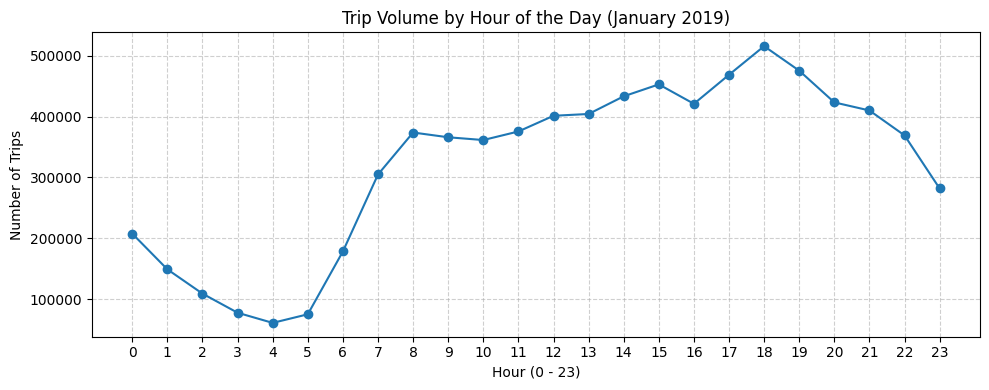

C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


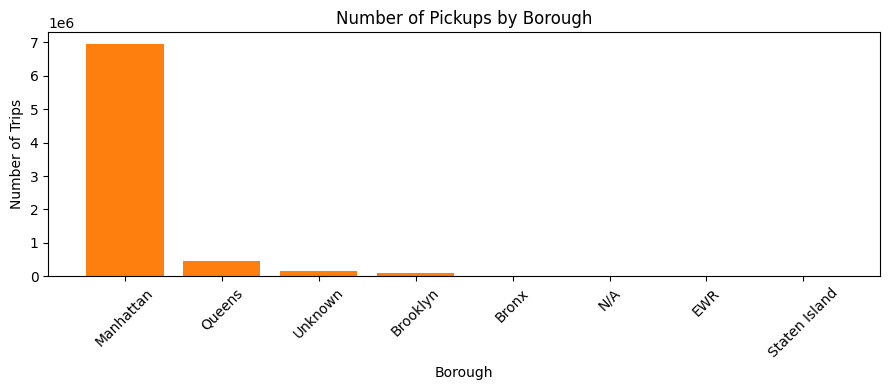

C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
C:\Users\nouha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


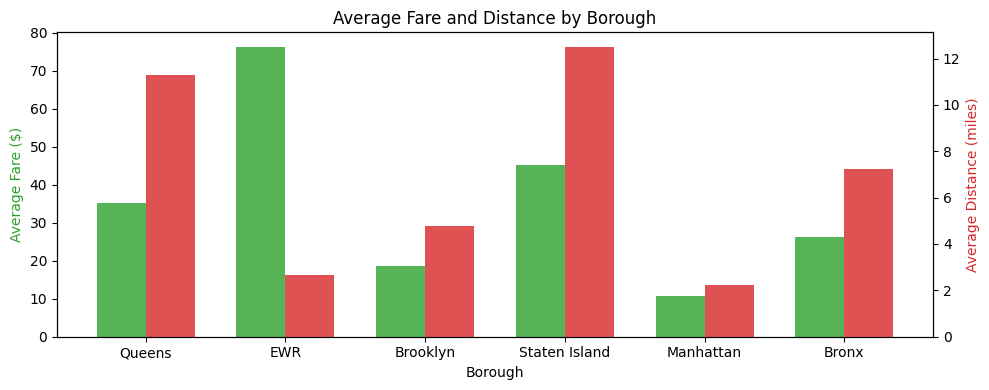

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Visualization: Trip volume by hour of the day
hourly_pd = (
    df_trips
    .groupBy(F.hour("tpep_pickup_datetime").alias("hour"))
    .count()
    .orderBy("hour")
    .toPandas()
)

plt.figure(figsize=(10, 4))
plt.plot(hourly_pd["hour"], hourly_pd["count"], marker="o", color="#1f77b4")
plt.title("Trip Volume by Hour of the Day (January 2019)")
plt.xlabel("Hour (0 - 23)")
plt.ylabel("Number of Trips")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# 2. Visualization: Pickups count by borough
borough_pd = (
    df_full
    .filter(F.col("PU_Borough").isNotNull())
    .groupBy("PU_Borough")
    .count()
    .orderBy(F.col("count").desc())
    .toPandas()
)

plt.figure(figsize=(9, 4))
plt.bar(borough_pd["PU_Borough"], borough_pd["count"], color="#ff7f0e")
plt.title("Number of Pickups by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Visualization: Average fare and distance by borough
avg_pd = (
    df_full
    .filter(F.col("PU_Borough").isin(["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR"]))
    .groupBy("PU_Borough")
    .agg(
        F.avg("trip_distance").alias("avg_distance"),
        F.avg("fare_amount").alias("avg_fare")
    )
    .toPandas()
)

x = np.arange(len(avg_pd["PU_Borough"]))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

rects1 = ax1.bar(x - width/2, avg_pd["avg_fare"], width, color="#2ca02c", alpha=0.8, label="Average Fare ($)")
rects2 = ax2.bar(x + width/2, avg_pd["avg_distance"], width, color="#d62728", alpha=0.8, label="Average Distance (miles)")

ax1.set_xlabel("Borough")
ax1.set_ylabel("Average Fare ($)", color="#2ca02c")
ax2.set_ylabel("Average Distance (miles)", color="#d62728")
ax1.set_xticks(x)
ax1.set_xticklabels(avg_pd["PU_Borough"])
plt.title("Average Fare and Distance by Borough")
plt.tight_layout()
plt.show()